# Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Step 2: Load the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Step 3: Basic EDA

In [7]:
df.duplicated().sum()

np.int64(0)

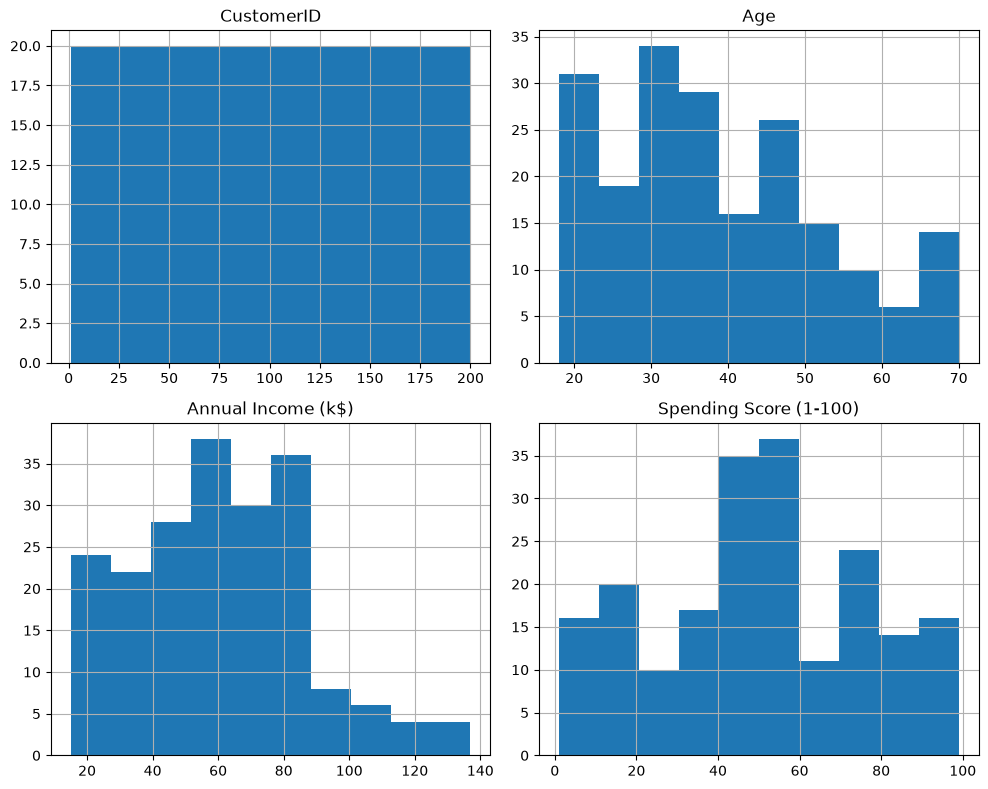

In [8]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Step 4: Select Features

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 5: Feature Scaling

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

# Step 6: Elbow Method

The Elbow Method helps us estimate the best number of clusters (**K**) by measuring the **Within-Cluster Sum of Squares (WCSS)**, also called **inertia**.

As K increases, WCSS decreases because each cluster contains fewer points. We look for the point where the improvement starts to slow down—the **"elbow."**

In [12]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

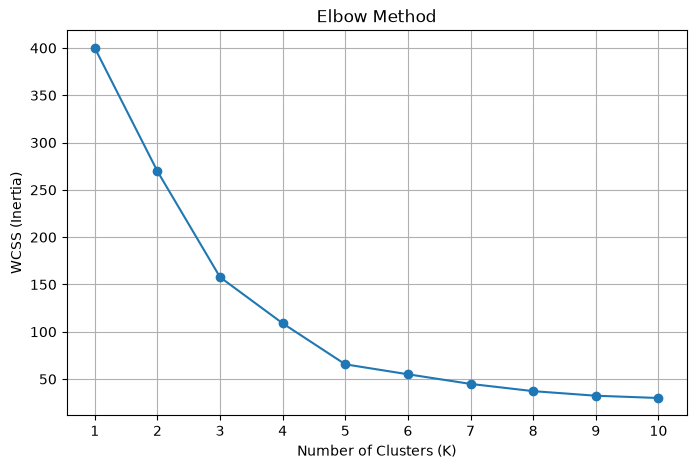

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

# Step 7: Silhouette Score
The Elbow Method can sometimes be subjective. The **Silhouette Score** provides a quantitative measure of clustering quality.

- Close to 1 → Well-separated clusters
- Around 0 → Overlapping clusters
- Less than 0 → Poor clustering

In [15]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

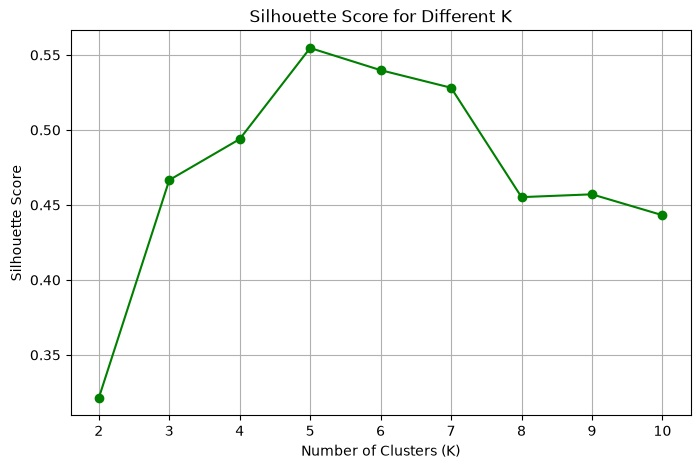

In [16]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,11))
plt.grid(True)
plt.show()

In [17]:
best_k = np.argmax(silhouette_scores) + 2
best_score = max(silhouette_scores)

print(f"Best K: {best_k}")
print(f"Best Silhouette Score: {best_score:.3f}")

Best K: 5
Best Silhouette Score: 0.555


# Step 8: Train the Final K-Means Model

In [18]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [19]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [20]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


# Step 9: Visualize Cluster

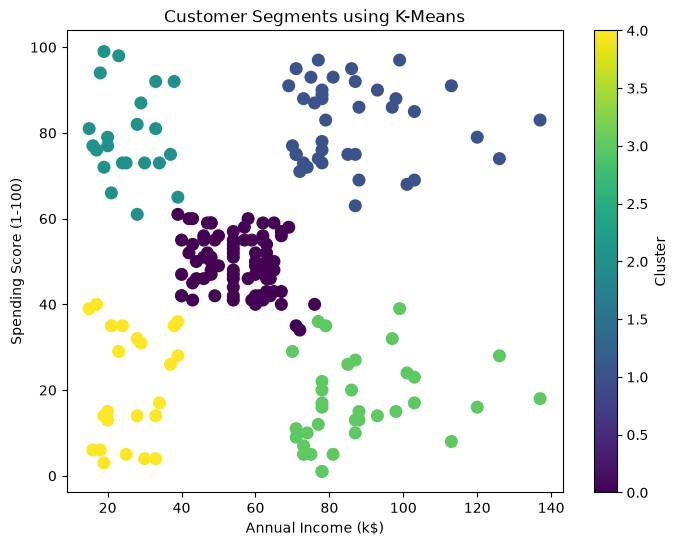

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=70
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(label="Cluster")
plt.show()

In [22]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

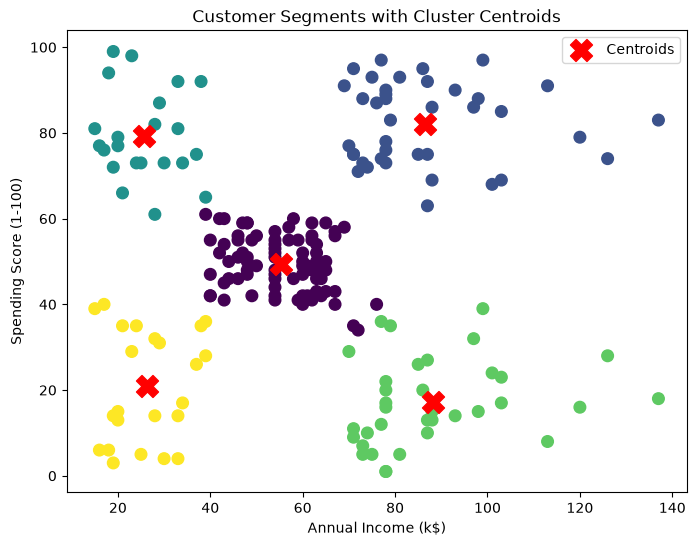

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=70
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("Customer Segments with Cluster Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [24]:
cluster_summary = (
    df.groupby("Cluster")[
        ["Annual Income (k$)", "Spending Score (1-100)"]
    ]
    .mean()
    .round(2)
)

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


In [25]:
cluster_summary["Customers"] = df.groupby("Cluster").size()

cluster_summary

,Annual Income (k$),Spending Score (1-100),Customers
Cluster,,,
0,55.30,49.52,81
1,86.54,82.13,39
2,25.73,79.36,22
3,88.20,17.11,35
4,26.30,20.91,23


# Step 10: PCA Visualization

In [26]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [27]:
X_pca[:5]

array([[-1.5371092 , -0.92220705],
       [-0.38416767, -2.07514858],
       [-2.41600197,  0.01066545],
       [-0.46698176, -1.93835476],
       [-1.45567848, -0.89567831]])

In [28]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-1.537109,-0.922207,4
1,-0.384168,-2.075149,2
2,-2.416002,0.010665,4
3,-0.466982,-1.938355,2
4,-1.455678,-0.895678,4


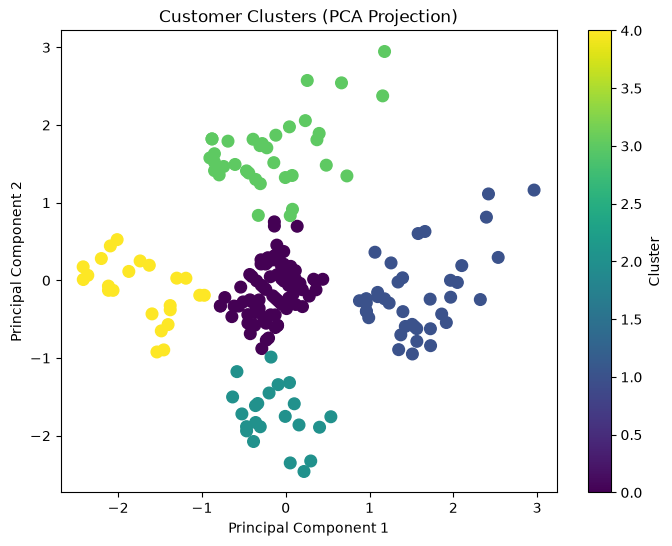

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=70
)

plt.title("Customer Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

In [30]:
centroids_pca = pca.transform(kmeans.cluster_centers_)

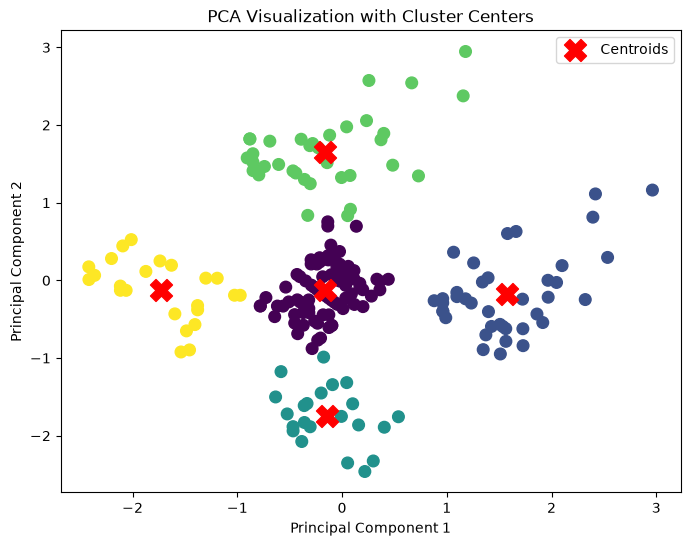

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=70
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("PCA Visualization with Cluster Centers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

In [32]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.50495142 0.49504858]
